In [1]:
from tauCC.src.taucc.taucc import CoClust
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tauCC.src.fairness_metrics import balance_gen
import os

In [2]:
clus = 3
groups = 2
matrix = np.load(f"datasets/synthetic/clus{clus}/matrix.npy")
matrix.shape

(1000, 1000)

In [3]:
dataset = f"clus{clus}_groups{groups}"
root = os.getcwd()
output_dir = root + f"/plots/synthetic/clus{clus}/groups{groups}/"

In [4]:
Sx = np.load(f"datasets/synthetic/clus{clus}/groups{groups}/sensitive_p1.0.npy")
Sx.shape

(1000,)

In [5]:
model = CoClust(initialization="random", verbose=True).fit(matrix)

Initialization step for (1000,1000)-siezed input matrix.
iteration 0, moving rows, n_clusters: (27, 30), n_moves: 906
Values of tau_x: 0.0042 and tau_y: 0.0006, for (27,30)-sized T at iteration: 0 (on rows).
iteration 1, moving rows, n_clusters: (4, 30), n_moves: 357
Values of tau_x: 0.0084 and tau_y: 0.0006, for (4,30)-sized T at iteration: 0 (on rows).
iteration 2, moving rows, n_clusters: (3, 30), n_moves: 14
Values of tau_x: 0.0084 and tau_y: 0.0006, for (3,30)-sized T at iteration: 0 (on rows).
iteration 3, moving rows, n_clusters: (3, 30), n_moves: 1
Values of tau_x: 0.0084 and tau_y: 0.0006, for (3,30)-sized T at iteration: 0 (on rows).
iteration 4, moving rows, n_clusters: (3, 30), n_moves: 0
Values of tau_x: 0.0084 and tau_y: 0.0006, for (3,30)-sized T at iteration: 0 (on rows).
iteration 5, moving columns, n_clusters: (3, 4), n_moves: 943
Values of tau_x: 0.2957 and tau_y: 0.2668, for (3,4)-sized T at iteration: 0 (on columns).
iteration 6, moving columns, n_clusters: (3, 3),

In [6]:
row_clus = np.array(model.row_labels_)
num_clus = len(row_clus)

In [7]:
individuals_taus_x = model.individual_taus_x

In [8]:
male = individuals_taus_x[Sx == 0]
female = individuals_taus_x[Sx == 1]

In [9]:
total_tau_male = np.sum(male)
total_tau_female = np.sum(female)
print("tau male: ", total_tau_male)
print("tau female: ", total_tau_female)

tau male:  0.11768711878013402
tau female:  0.07695238279223873


In [10]:
individuals_taus_x = np.array(individuals_taus_x).reshape(-1, 1)
scaler = MinMaxScaler()
tau_norm = scaler.fit_transform(individuals_taus_x).flatten()
tau_norm

array([0.1145372 , 0.7310962 , 0.69400729, 0.07782363, 0.11208479,
       0.03456164, 0.75748178, 0.84517916, 0.82986781, 0.79128737,
       0.80187775, 0.70877948, 0.12952351, 0.14569807, 0.07534619,
       0.12743494, 0.78220636, 0.64747403, 0.85862921, 0.80081895,
       0.08919418, 0.77432895, 0.705367  , 0.79546918, 0.85305254,
       0.13450405, 0.76251325, 0.06112171, 0.10913167, 0.12045475,
       0.78538819, 0.10279691, 0.78502531, 0.78548523, 0.84578044,
       0.86819266, 0.73444183, 0.78517504, 0.83686539, 0.77468308,
       0.73109252, 0.85963515, 0.81645777, 0.81587164, 0.78099271,
       0.17401121, 0.08768444, 0.84386409, 0.78234876, 0.19414381,
       0.78309184, 0.09380065, 0.81557031, 0.79506452, 0.08685926,
       0.68968955, 0.76360354, 0.14038525, 0.84705482, 0.17262276,
       0.74986869, 0.89313094, 0.70107503, 0.04357515, 0.17809242,
       0.18640958, 0.76207726, 0.83331136, 0.76850965, 0.79677982,
       0.82307631, 0.16094528, 0.84881679, 0.14054855, 0.76542

In [11]:
tau_x_male = tau_norm[Sx == 0]
tau_x_female = tau_norm[Sx == 1]
if groups == 3:
    tau_x_group3 = tau_norm[Sx == 2]

In [12]:
import matplotlib.pyplot as plt

def create_plot_tau_distribution_per_group(group1, group2, dataset, algorithm, min_value=0, max_value=1, group3=None):
    
    plt.hist(group1, bins=20, alpha=0.5, color="#4d77b1", edgecolor="black", label="Group 1")
    plt.hist(group2, bins=20, alpha=0.5, color="#e08225", edgecolor="black", label="Group 2")
    
    if groups == 3 and tau_x_group3 is not None:
        plt.hist(group3, bins=20, alpha=0.5, color="#009e73", edgecolor="black", label="Group 3")
    
    plt.title(f"{dataset} - {algorithm}\n Distribution of $\sigma$ per protected group")
    plt.xlabel("similarity values")
    plt.ylabel("counts")
    plt.legend()
    plt.xlim([min_value, max_value])
    
    filename=f"{dataset}_{algorithm}_sigma_per_group.png"
    
    plt.tight_layout()
    plt.savefig(
        f"{output_dir}/{filename}",
        dpi=300,
        bbox_inches="tight",
    )


In [13]:
import matplotlib.pyplot as plt
import numpy as np

def create_plot_tau_distribution_per_group(group1, group2, dataset, algorithm, min_value=0, max_value=1, group3=None):
    
    bins = np.linspace(min_value, max_value, 21)  # 20 bins fissi e allineati tra i gruppi

    def to_percentage(data, bins):
        counts, edges = np.histogram(data, bins=bins)
        return counts / counts.sum() * 100, edges

    pct1, edges1 = to_percentage(group1, bins)
    pct2, edges2 = to_percentage(group2, bins)

    width = (edges1[1] - edges1[0])

    plt.bar(edges1[:-1], pct1, width=width, alpha=0.5, color="#4d77b1",
            edgecolor="black", label="Group 1", align="edge")
    plt.bar(edges2[:-1], pct2, width=width, alpha=0.5, color="#e08225",
            edgecolor="black", label="Group 2", align="edge")

    if group3 is not None:
        pct3, edges3 = to_percentage(group3, bins)
        plt.bar(edges3[:-1], pct3, width=width, alpha=0.5, color="#009e73",
                edgecolor="black", label="Group 3", align="edge")

    plt.title(f"{dataset} - {algorithm}\n Distribution of $\\sigma$ per protected group")
    plt.xlabel("similarity values")
    plt.ylabel("percentage (%)")
    plt.legend()
    plt.xlim([min_value, max_value])

    filename = f"{dataset}_{algorithm}_sigma_per_group_percent.png"

    plt.tight_layout()
    plt.savefig(
        f"{output_dir}/{filename}",
        dpi=300,
        bbox_inches="tight",
    )

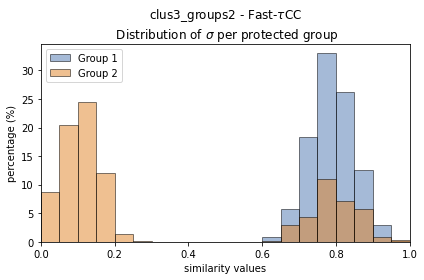

In [14]:
#tau_x_male_round = np.round(tau_x_male,5)
#tau_x_female_round = np.round(tau_x_female,5)
#min_value_round = np.round(min_value,5)
#max_value_round = np.round(max_value,5)
#create_plot_distributions_2_groups(tau_x_male_round, tau_x_female_round, min_value_round, max_value_round)

algorithm = r"Fast-$\tau$CC"

if groups == 3:
    create_plot_tau_distribution_per_group(group1=tau_x_male, group2=tau_x_female, group3=tau_x_group3, dataset=dataset, algorithm=algorithm)
else:
    create_plot_tau_distribution_per_group(group1=tau_x_male, group2=tau_x_female, dataset=dataset, algorithm=algorithm)

In [15]:
print("tau_x mean values:")
print("- group1: ", np.mean(tau_x_male))
print("- group2: ", np.mean(tau_x_female))
if groups == 3:
    print("- group3: ", np.mean(tau_x_group3))


print()
print("tau_x median values:")
print("- group1: ", np.median(tau_x_male))
print("- group2: ", np.median(tau_x_female))
if groups == 3:
    print("- group3: ", np.median(tau_x_group3))

tau_x mean values:
- group1:  0.7896080064663787
- group2:  0.3331149414953108

tau_x median values:
- group1:  0.7892003301265557
- group2:  0.14050531037637198


In [39]:
from tauCC.src.taucc.taucc_fair_rows_cols_max import FairCoclus

In [40]:
if clus==3 and groups==3:
    alpha = [0.75,1.0,0.75]
if clus==3 and groups==2: 
    #alpha = [0.8,0.9]
    alpha = [1.0,1.0]

In [41]:
balance=0.0
model = None
fair_row_clus = None
fair_col_clus = None
while balance < 0.80:
    model = FairCoclus(initialization="random", verbose=True).fit(matrix, Sx=Sx, fair_row_parameters=np.array(alpha))
    fair_row_clus = np.array(model.row_labels_)
    fair_col_clus = np.array(model.column_labels_)
    balance = balance_gen(Sx, fair_row_clus)

Sx ratio groups in dataset: [0.5, 0.5]
Initialization step for (1000,1000)-sized input matrix.
iteration 0, moving rows, n_clusters: (10, 10), n_moves: 865
Values of tau_x: 0.0004 and tau_y: 0.0004, for (10,10)-sized T at iteration: 0 (on rows).
iteration 1, moving rows, n_clusters: (9, 10), n_moves: 506
Values of tau_x: 0.0005 and tau_y: 0.0005, for (9,10)-sized T at iteration: 0 (on rows).
iteration 2, moving rows, n_clusters: (9, 10), n_moves: 347
Values of tau_x: 0.0005 and tau_y: 0.0004, for (9,10)-sized T at iteration: 0 (on rows).
iteration 3, moving rows, n_clusters: (8, 10), n_moves: 313
Values of tau_x: 0.0006 and tau_y: 0.0005, for (8,10)-sized T at iteration: 0 (on rows).
iteration 4, moving rows, n_clusters: (8, 10), n_moves: 231
Values of tau_x: 0.0006 and tau_y: 0.0005, for (8,10)-sized T at iteration: 0 (on rows).
iteration 5, moving rows, n_clusters: (8, 10), n_moves: 146
Values of tau_x: 0.0006 and tau_y: 0.0005, for (8,10)-sized T at iteration: 0 (on rows).
iteration

Values of tau_x: 0.1992 and tau_y: 0.1992, for (2,2)-sized T at iteration: 4 (on columns).
Final values of tau_x: 0.1992 and tau_y: 0.1992, for (2,2)-sized T.
Runtime: 1.9279 seconds.


In [42]:
balance

1.0

In [43]:
fair_individuals_taus_x = model.individual_taus_x
fair_male = fair_individuals_taus_x[Sx==0]
fair_female = fair_individuals_taus_x[Sx==1]
print("tau male: ", np.sum(fair_male))
print("tau female: ", np.sum(fair_female))

tau male:  0.0775733340197125
tau female:  0.02192932493887976


In [44]:
fair_individuals_taus_x = model.individual_taus_x
fair_individuals_taus_x = np.array(fair_individuals_taus_x).reshape(-1, 1)
scaler = MinMaxScaler()
fair_tau_norm = scaler.fit_transform(fair_individuals_taus_x).flatten()
fair_tau_norm

array([0.58861656, 0.71681813, 0.73556912, 0.56964423, 0.57312728,
       0.56750854, 0.75945544, 0.94342466, 0.78645591, 0.76131346,
       0.77954614, 0.764348  , 0.60984889, 0.59253649, 0.58268524,
       0.56724066, 0.76965417, 0.86254756, 0.78819943, 0.92379411,
       0.5588378 , 0.76561974, 0.88738906, 0.76280838, 0.77802396,
       0.58100204, 0.75280191, 0.56062203, 0.59271895, 0.60012193,
       0.76487611, 0.59827555, 0.780381  , 0.76463731, 0.94714069,
       0.77987616, 0.90210562, 0.92656077, 0.77172771, 0.78110902,
       0.89961082, 0.94933455, 0.76318311, 0.78056347, 0.926652  ,
       0.58899129, 0.57767818, 0.945174  , 0.91928791, 0.60822967,
       0.74898302, 0.56996844, 0.93187857, 0.77817153, 0.57870133,
       0.72109135, 0.91544176, 0.58512188, 0.79178534, 0.58804192,
       0.9109123 , 0.81542124, 0.71380103, 0.56268976, 0.61024106,
       0.61699164, 0.76488774, 0.93802726, 0.76670504, 0.92700346,
       0.93265711, 0.59424113, 0.94467497, 0.60661045, 0.75550

In [45]:
fair_tau_x_male = fair_tau_norm[Sx == 0]
fair_tau_x_female = fair_tau_norm[Sx == 1]

if groups==3:
    fair_tau_x_group3 = fair_tau_norm[Sx == 2]

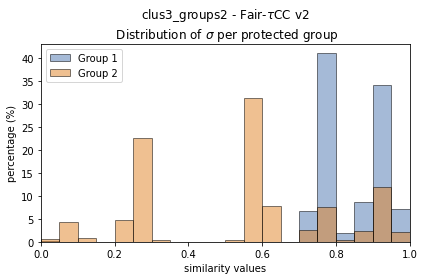

In [46]:
algorithm = r"Fair-$\tau$CC v2"

if groups == 3:
    create_plot_tau_distribution_per_group(group1=fair_tau_x_male, group2=fair_tau_x_female, group3=fair_tau_x_group3, dataset=dataset, algorithm=algorithm)
else:
    create_plot_tau_distribution_per_group(group1=fair_tau_x_male, group2=fair_tau_x_female, dataset=dataset, algorithm=algorithm)

In [47]:
print("tau_x mean values:")
print("- group1: ", np.mean(fair_tau_x_male))
print("- group2: ", np.mean(fair_tau_x_female))

if groups == 3:
    print("- group3: ", np.mean(fair_tau_x_group3))

print()
print("tau_x median values:")
print("- group1: ", np.median(fair_tau_x_male))
print("- group2: ", np.median(fair_tau_x_female))

if groups == 3:
    print("- group3: ", np.median(fair_tau_x_group3))

tau_x mean values:
- group1:  0.8439678517905083
- group2:  0.5430012362239245

tau_x median values:
- group1:  0.8384301165143739
- group2:  0.5795420139255938


In [48]:
values, count = np.unique(fair_row_clus,return_counts=True)

In [49]:
gender_count = np.unique(Sx,return_counts=True)[1]

for clus in values:
    _, counts_clus = np.unique(Sx[np.where(fair_row_clus == clus)], return_counts=True)
    print("cluster ", clus)
    print("groups in clus: ", counts_clus / gender_count)
    print("cluster size: ", np.sum(counts_clus))
    print("--------")

cluster  0
groups in clus:  [0.5 0.5]
cluster size:  500
--------
cluster  1
groups in clus:  [0.5 0.5]
cluster size:  500
--------


Test: compute_taus for other algorithms

In [ ]:
import numpy as np

In [ ]:
dataset = "amazon"
sensitive = "gender"

In [ ]:
V = np.load(f"datasets/{dataset}/matrix.npy")
row_clus = np.load(f"results/{dataset}/{sensitive}/taucc_fair_max/init_random/best_run/run8/row_assignment.npy")
col_clus = np.load(f"results/{dataset}/{sensitive}/taucc_fair_max/init_random/best_run/run8/col_assignment.npy")

In [ ]:
sum_entries = np.sum(V)
V_norm = V/sum_entries

In [ ]:
def get_row_col_incidence(clus):
    num_clus = len(np.unique(clus))
    num_items = len(clus)
    incidence = np.zeros((num_items, num_clus))
    incidence[np.arange(0,num_items, dtype=int), clus.astype(int)] = 1
    return incidence

In [ ]:
def update_dataset(dataset, row_incidence, col_incidence, dimension):
    if dimension == 0:
        #new_t = np.zeros((self._n_documents, self._n_col_clusters), dtype = float)
        new_t = np.dot(dataset, col_incidence)
    else:
        #new_t = np.zeros((self._n_row_clusters, self._n_features), dtype = float)
        new_t = np.dot(row_incidence.T, dataset)
    return new_t
    

def contingency_matrix(dataset, dimension, row_clus, col_clus):
    row_incidence = get_row_col_incidence(row_clus)
    col_incidence = get_row_col_incidence(col_clus)
    dataset = update_dataset(dataset, row_incidence, col_incidence, dimension)
    if dimension == 0:
        new_t = np.dot(row_incidence.T, dataset)
    else:
        new_t = np.dot(dataset, col_incidence)
    return dataset, new_t


def compute_taus(dataset, dimension, row_clus, col_clus):
    _, T = contingency_matrix(dataset, dimension, row_clus, col_clus)
    tot_per_x = np.sum(T, 1)
    tot_per_y = np.sum(T, 0)
    t_square = np.power(T, 2)
    a_x = np.sum(np.nan_to_num(np.true_divide(np.sum(t_square, axis = 0), tot_per_y)))
    b_x = np.sum(np.power(tot_per_x, 2))
    a_y = np.sum(np.nan_to_num(np.true_divide(np.sum(t_square, axis = 1), tot_per_x)))
    b_y = np.sum(np.power(tot_per_y, 2))
    tau_x = np.nan_to_num(np.true_divide(a_x - b_x, 1 - b_x))
    tau_y = np.nan_to_num(np.true_divide(a_y - b_y, 1 - b_y))
    return tau_x, tau_y, (a_x - b_x), (a_y - b_y)


In [ ]:
_, T = contingency_matrix(V_norm, 0, row_clus, col_clus)

In [ ]:
rows_tau_x, rows_tau_y, _, _ = compute_taus(V_norm, 0, row_clus, col_clus)
cols_tau_x, cols_tau_y, _, _ = compute_taus(V_norm, 1, row_clus, col_clus)
print("rows")
print("tau_x: ", rows_tau_x)
print("tau y: ", rows_tau_y)

print("cols")
print("tau_x: ", cols_tau_x)
print("tau y: ", cols_tau_y)
